In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
path = "../data/"
features = path + "features.csv"

df = pd.read_csv(features)
df.describe()

,Unnamed: 0,Asymmetry,Border,HSV_Hue_Variance,HSV_Saturation_Variance,HSV_Value_Variance,Cancerous
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,0.422321,0.231408,0.036252,0.007278,0.005974,0.500000
std,144.481833,0.444572,0.096436,0.107949,0.006912,0.007281,0.500501
min,0.000000,0.034817,0.004772,0.000000,0.000000,0.000000,0.000000
25%,124.750000,0.143048,0.194829,0.001138,0.002332,0.001563,0.000000
50%,249.500000,0.240409,0.253049,0.003581,0.004868,0.003339,0.500000
75%,374.250000,0.459282,0.280625,0.014847,0.009772,0.007616,1.000000
max,499.000000,1.921557,1.697819,0.854368,0.035941,0.071958,1.000000


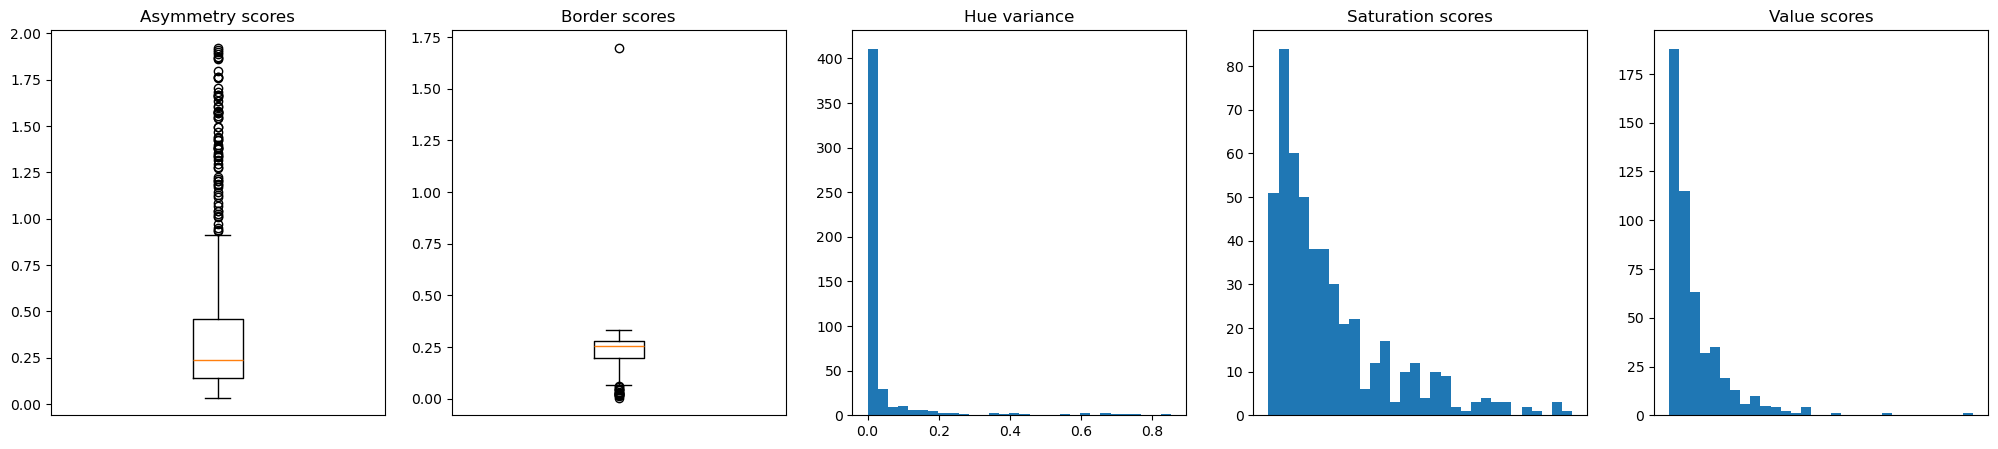

In [3]:
plt.figure(figsize=(25,5))
plt.subplot(1,5,1)
plt.boxplot(df["Asymmetry"])
plt.title("Asymmetry scores")
plt.xticks([])

plt.subplot(1,5,2)
plt.boxplot(df["Border"])
plt.title("Border scores")
plt.xticks([])

plt.subplot(1,5,3)
plt.hist(df["HSV_Hue_Variance"],bins=30)
plt.title("Hue variance")

plt.subplot(1,5,4)
plt.hist(df["HSV_Saturation_Variance"],bins=30)
plt.title("Saturation scores")
plt.xticks([])

plt.subplot(1,5,5)
plt.hist(df["HSV_Value_Variance"],bins=30)
plt.title("Value scores")
plt.xticks([])
plt.show()

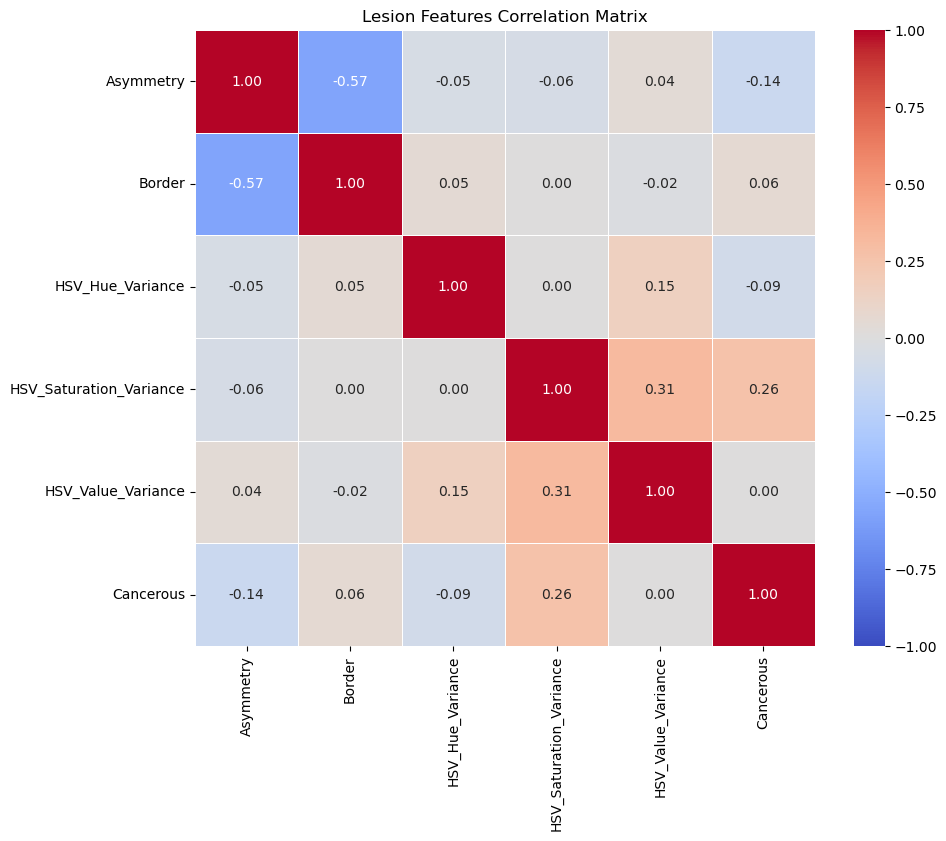

In [8]:
# Make the canvas a bit bigger
plt.figure(figsize=(10, 8))

# Drop the junk column (errors='ignore' just means it won't crash if you already dropped it)
df_clean = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Draw the heatmap with the proper Data Science settings
sns.heatmap(data=df_clean.corr(numeric_only=True), 
            annot=True,         # Turns on the numbers!
            fmt=".2f",          # Rounds the numbers to 2 decimal places
            cmap="coolwarm",    # Uses a Blue-White-Red color scale
            vmin=-1,            # Locks the absolute minimum to -1
            vmax=1,             # Locks the absolute maximum to +1
            center=0,           # Forces exactly 0 to be neutral white
            linewidths=0.5)     # Adds a tiny grid line to separate boxes

plt.title("Lesion Features Correlation Matrix")
plt.show()

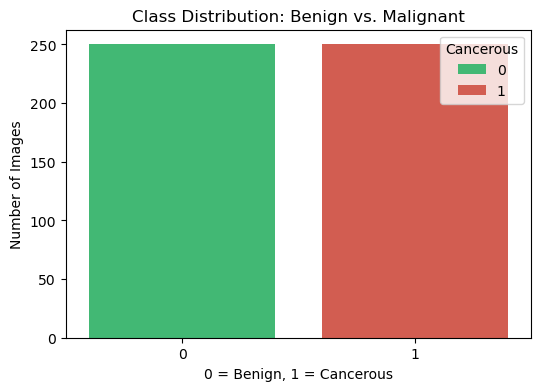

In [16]:
plt.figure(figsize=(6, 4))
# 'palette' makes the 0s green (healthy) and 1s red (danger)
sns.countplot(data=df, x='Cancerous',hue="Cancerous", palette=['#2ecc71', '#e74c3c'])
plt.title("Class Distribution: Benign vs. Malignant")
plt.xlabel("0 = Benign, 1 = Cancerous")
plt.ylabel("Number of Images")
plt.show()

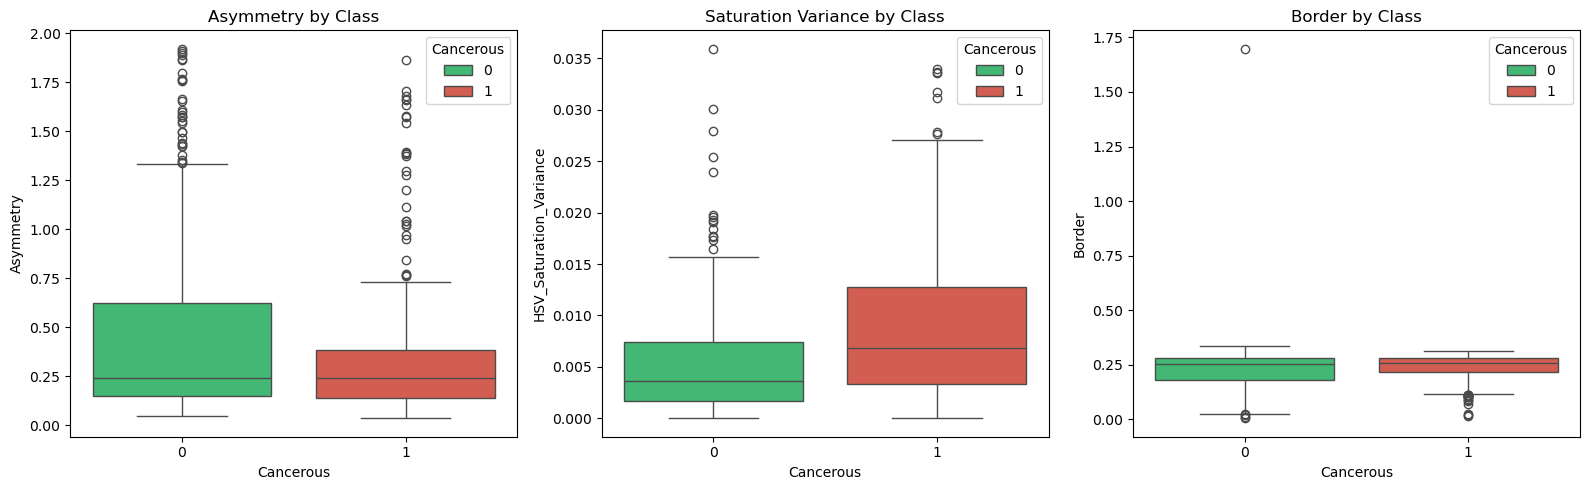

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Asymmetry
sns.boxplot(data=df, x='Cancerous', y='Asymmetry',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title("Asymmetry by Class")

# Plot 2: Saturation Variance
sns.boxplot(data=df, x='Cancerous', y='HSV_Saturation_Variance',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title("Saturation Variance by Class")

# Plot 3: Border
sns.boxplot(data=df, x='Cancerous', y='Border',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title("Border by Class")

plt.tight_layout()
plt.show()

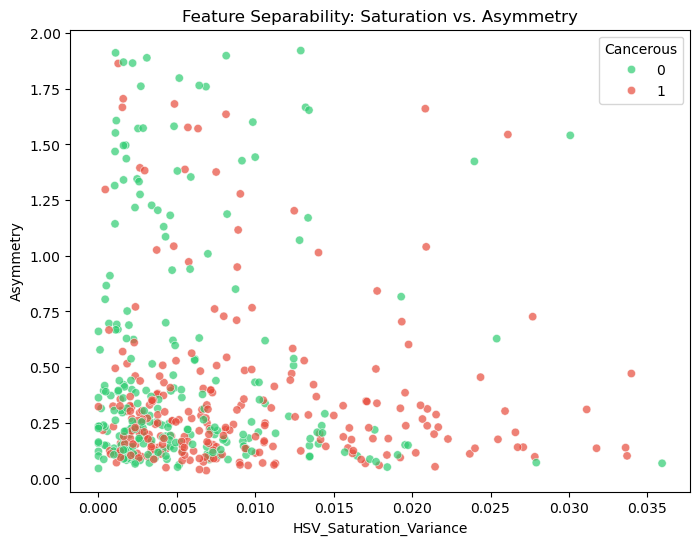

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, 
                x='HSV_Saturation_Variance', 
                y='Asymmetry', 
                hue='Cancerous', 
                palette=['#2ecc71', '#e74c3c'], 
                alpha=0.7) # alpha makes the dots slightly transparent so you can see overlaps

plt.title("Feature Separability: Saturation vs. Asymmetry")
plt.show()

In [18]:
df["Cancerous"].value_counts()

Cancerous
0    250
1    250
Name: count, dtype: int64